In [1]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
sim = AerSimulator(method='statevector')

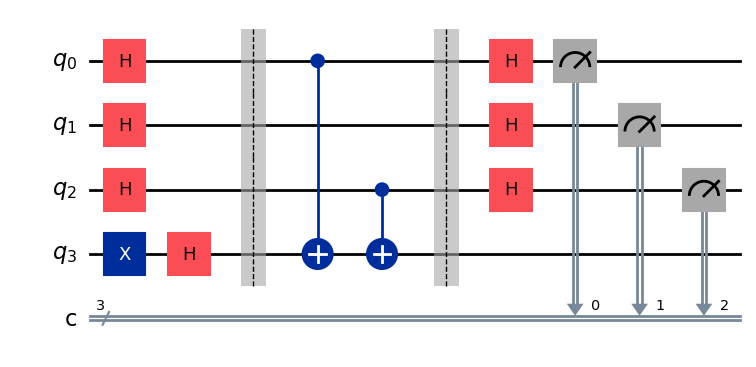

In [2]:
# create a bv_circuit
n=int(input("Enter number of qubits:" ))

circuit=QuantumCircuit(n+1,n)
# apply x gate on the last qubit
circuit.x(n)
# apply Hadamard on all qubits
circuit.h(range(n+1))
circuit.barrier()

# create orecle Uf
secret = str(input("Enter a secret qubit is equvivalanet to input qubits:" ))
if len(secret)==n:
    secret = secret[::-1]
    for i in range(n):
        if secret[i] == '1':
            circuit.cx(i, n)
else:
    print("Enter secret qubit again")
circuit.barrier()

# apply Hadamard on all qubits
circuit.h(range(n))
circuit.measure(range(n),range(n))

circuit.draw('mpl', filename='bv_circuit.png')

In [3]:
result = sim.run(transpile(circuit, sim), shots=1024).result()
counts = result.get_counts()
print("Measurement results:", counts)

Measurement results: {'101': 1024}


In [4]:
from qiskit_ibm_runtime import SamplerV2 
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


In [5]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2,
)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Load IBM account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Select least busy real device
backend = service.least_busy(
    simulator=False,
    operational=True
)

print("Running on:", backend.name)

# Transpile circuit for target backend
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)

isa_circuit = pm.run(circuit)

# Create sampler
sampler = SamplerV2(mode=backend)

# Run job
job = sampler.run([isa_circuit], shots=1024)

print("Job ID:", job.job_id())

result = job.result()

# Extract counts
counts = result[0].data.c.get_counts()

print("Measurement results:")
print(counts)


qiskit_runtime_service.__init__:WARNING:2026-06-23 16:54:02,505: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-23 16:54:02,824: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-23 16:54:05,085: Using instance: open-instance, plan: open


Running on: ibm_marrakesh
Job ID: d8tf4tlposuc738ol0o0
Measurement results:
{'101': 965, '100': 20, '111': 18, '001': 18, '110': 1, '000': 2}


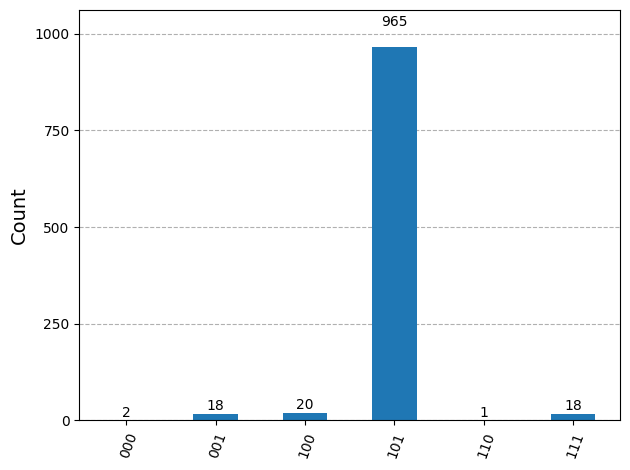

In [6]:
plot_histogram(counts)